# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [4]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
 plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:

# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
print(usage.isna().sum())
print(usage.isna().mean()) # cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- en users las columnas city y churn_date tienen valores faltantes,mientras que en la columna usage los valores faltantes estan en date,duration y lenght.
- Indica qué harías: ¿imputar, eliminar, ignorar?
- con city tengo el 11,75%, por lo tanto se investigaria la importancia de esta fila antes de tomar una decision, con churn_date tengo el 88,35% los valores no representan un error pero es poco confiable por lo tanto deben mantenerse sin imputar ni eliminar.
- en cuanto a los valores en usage, date me representa el 0,125% de los datos por lo tanto se puede rellenar o eliminar esta fila; en cuanto duration y lenght me representan el 55,19% y 44,74% respectivamente, asi que antes de tomar una decision se debe investigar la importancia de estos datos y como se relacionan para tener una decision acertada.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
users.describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene la media y la mediana iguales,lo que significa que los datos estan distribuidos de forma uniforme y simetrica.
- La columna `age` tiene un sentinel(-999) ya que esa edad es imposible de obtener por lo tanto es un dato sin sentido real.

In [14]:
usage.describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas id y user_id poseen la misma media y mediana, mientras que en la columna duracion, se encuentra un sentinel(0) ya que es imposible que una llamada dure 0 segundos y ya por ultimo en la columna lenght se encuentra un outlier(1490)un valor poco probable pero posible...

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for columna in columnas_user:
    print(users[columna].value_counts(normalize=True, dropna=False) * 100)


Bogotá      20.200
CDMX        18.250
Medellín    15.400
NaN         11.725
GDL         11.250
Cali        10.600
MTY         10.175
?            2.400
Name: city, dtype: float64
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


- La columna `city` Bogota es la ciudad con mas usuarios y un simbolo (?) que no sabemos que tipo de dato puede ser al igual que NaN que es un valor ausente...
- La columna `plan` el plan basico es el que mas usan los usuarios...

In [16]:
# explorar columna categórica de usage
usage['type'].value_counts(normalize=True, dropna=False) * 100
# completa el código

text    55.23
call    44.77
Name: type, dtype: float64

- La columna `type` muestra dos categorias, tipo texto y tipo llamada...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- en la columna city se encontraron un valor sentinel(?) y un valor nulo(NaN) 
- ¿Qué acción tomarías?
- reeemplazaria el sentinel(?)  por un valor nulo de pandas (pd.NA)
-  el NaN si no es una variable clave se puede dejar tal como esta.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')# completa el código

In [19]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()



2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se encuentran datos desde 2022 hasta 2026 lo cual es un problema ya que solo puede haber datos hasta el 2024 ... haz doble clic en este bloque y escribe qué ves.

In [20]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, solo hay datos del 2024 por lo tanto todos los datos estan dentro de la fecha estipulada. ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- si aparecen 40 datos en el año 2026, año que no ha transcurrido al momento de guardar los datos.
- ¿Qué harías con ellas?
- reemplazar ese valor por pd.NaT (que es el equivalente de nulo para fechas).

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration_isna'] = usage['duration'].isna()
usage.groupby('type')['duration_isna'].mean() * 100

type
call     0.000000
text    99.927576
Name: duration_isna, dtype: float64

In [25]:
# Verificación MAR en usage (Missing At Random) para length
usage['length_isna'] = usage['length'].isna()
usage.groupby('type')['length_isna'].mean() * 100

type
call    99.932991
text     0.000000
Name: length_isna, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Se analizó la distribución de valores faltantes en las variables duration y length en función del tipo de registro (type).

Los resultados muestran que los valores nulos en duration se concentran casi exclusivamente en los registros de tipo text, mientras que los nulos en length se concentran en los registros de tipo call.

Esto indica que los valores faltantes no son aleatorios, sino que dependen del tipo de uso registrado. Por lo tanto, los nulos pueden clasificarse como Missing At Random (MAR) o incluso como datos estructuralmente ausentes, ya que cada variable solo aplica a un tipo específico de evento.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum','is_call':'sum','duration':'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes','is_call':'cant_llamadas','duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [34]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = user_profile=pd.merge(users,usage_agg,on="user_id",how="left") 
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [35]:
# Resumen estadístico de las columnas numéricas
user_profile[["age","cant_llamadas","cant_mensajes","cant_minutos_llamada"]].describe() 

,age,cant_llamadas,cant_mensajes,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,4.478120,5.524381,23.317054
std,17.690408,2.144238,2.358416,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,3.000000,4.000000,11.120000
50%,47.000000,4.000000,5.000000,19.780000
75%,63.000000,6.000000,7.000000,31.415000
max,79.000000,15.000000,17.000000,155.690000


In [36]:
# Distribución porcentual del tipo de plan
(user_profile['plan'].value_counts(normalize=True)) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

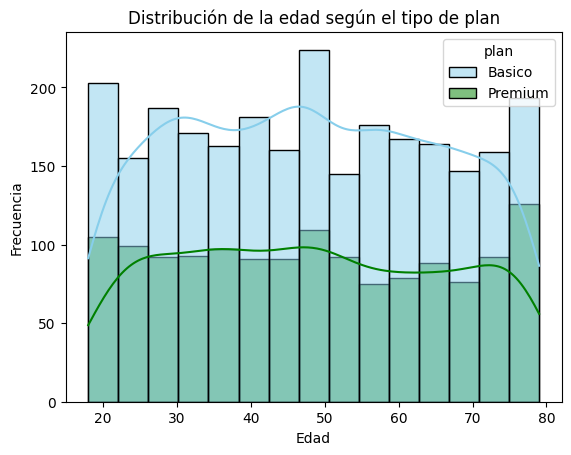

In [37]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan',palette=['skyblue', 'green'],bins=15,kde=True)
plt.title('Distribución de la edad según el tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
- La distribución de edad es simétrica, sin sesgo notable.
- Los usuarios del plan Premium se concentran entre los 20 y 50 años.

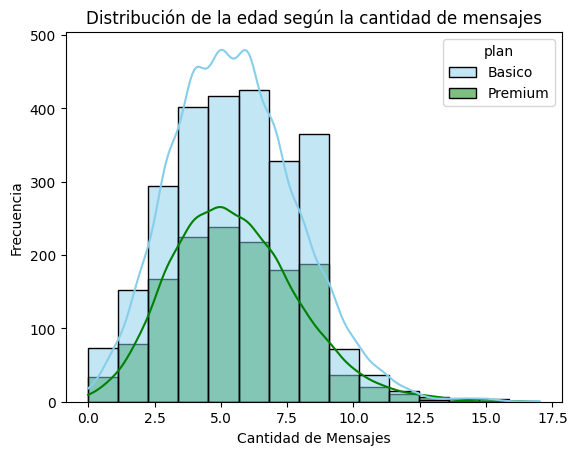

In [64]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan',palette=['skyblue', 'green'],bins=15,kde=True)
plt.title('Distribución de la edad según la cantidad de mensajes')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
- La distribucion es asimetrica pues es sesgada hacia la derecha.
- La distribución sesgada a la derecha significa que la mayoría de los valores se concentran en la parte izquierda (valores bajos), y hay muy pocos valores altos que "jalan" la cola hacia la derecha.

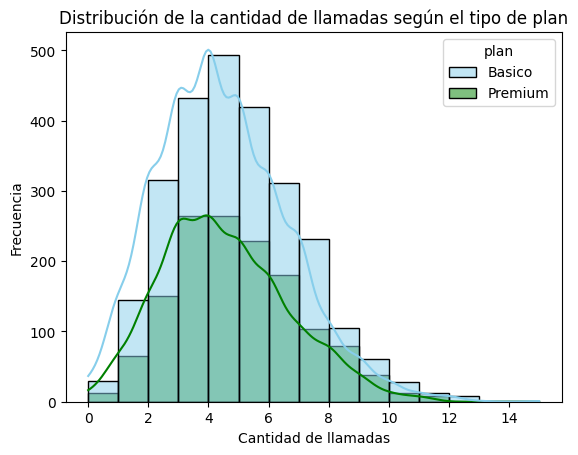

In [39]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x='cant_llamadas', hue='plan',palette=['skyblue', 'green'],bins=15,kde=True)
plt.title('Distribución de la cantidad de llamadas según el tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')

plt.show()


💡Insights: 
- la Distribución es asimetrica sesgada hacia la derecha
- se ve una frecuencia mas alta de llamadas en el plan basico pero esto es debido principalmente a que mas usuarios tienen el plan basico.
- los usuarios de ambos planes tienden a hacer las mismas llamadas pero los usuarios premium lo hacen con menor frecuencia.
- 

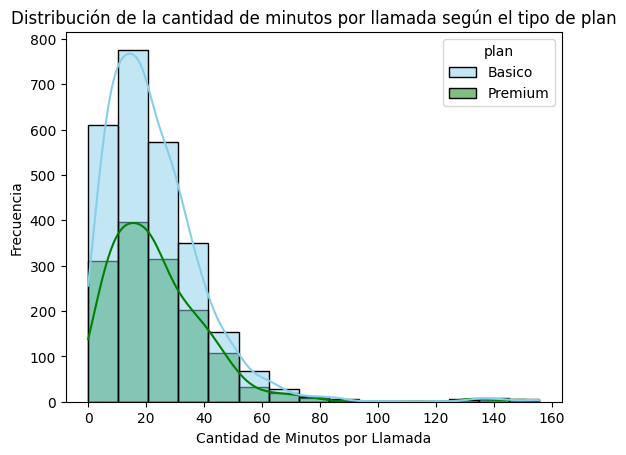

In [40]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan',palette=['skyblue', 'green'],bins=15,kde=True)
plt.title('Distribución de la cantidad de minutos por llamada según el tipo de plan')
plt.xlabel('Cantidad de Minutos por Llamada')
plt.ylabel('Frecuencia')

plt.show()


💡Insights: 
- la distribucion es asimetrica sesgada hacia la derecha
- se onserva que los usuarios del plan basico gastan los mismos minutos por llamada que los del premium, pero con mas frecuencia, esto se da debido a que mas clientes usan el plan basico que los del premium.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

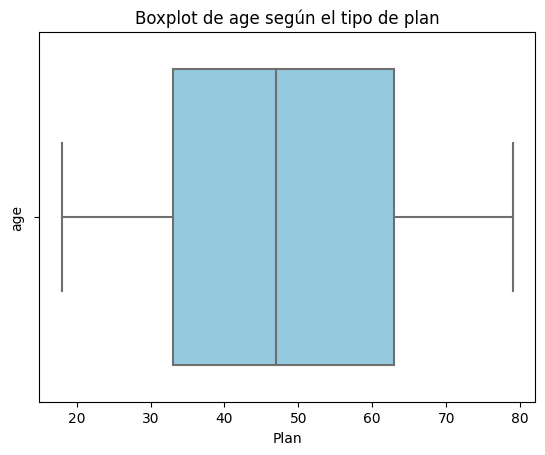

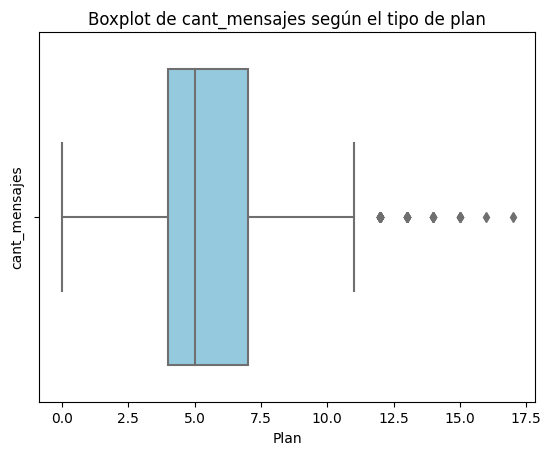

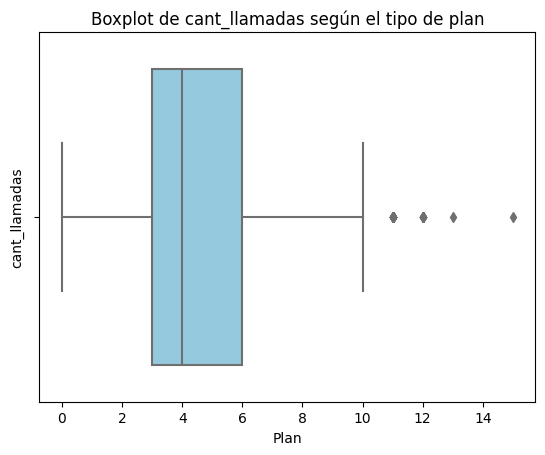

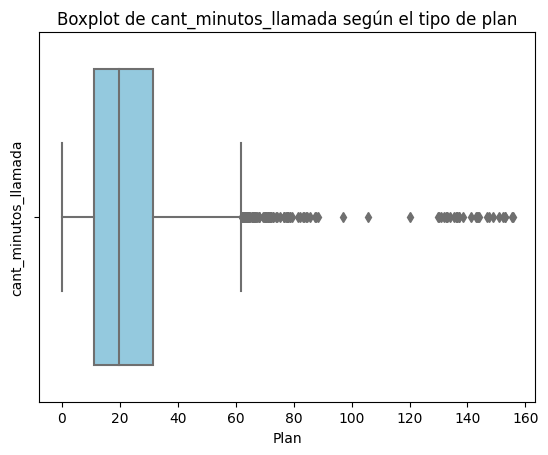

In [44]:
# Visualizando usando BoxPlot 


columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col, hue='plan',palette=['skyblue', 'green'])
    plt.title(f'Boxplot de {col} según el tipo de plan')
    plt.xlabel('Plan')
    plt.ylabel(col)
    plt.show()
    


      



💡Insights: 
- Age: tiene distribucion simetrica y no presenta outliers
- cant_mensajes: Distribución asimétrica sesgada a la derechacCon outliers a la derecha y ambos planes(basico y premium) se comportan de manera similar ...
- cant_llamadas: Distribución asimétrica sesgada a la derecha,con menos outliers a la derecha y ambos planes se comportan de manera similar
- cant_minutos_llamada: la distribucion es asimetrica sesgada a la derecha pero se va alejando hacia la derecha esto se debe a que deben haber datos raros y van formando esa cola larga a la derecha ...

In [56]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']
for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    print('primer cuartil:',Q1)
    Q3=user_profile[col].quantile(0.75)
    print('tercer cuartil:',Q3)
    IQR=Q3-Q1
    print('IQR:',IQR)
    limite_inferior = Q1 - 1.5 * IQR
    print(limite_inferior)
    limite_superior = Q3 + 1.5 * IQR
    print(limite_superior)
    
    

primer cuartil: 4.0
tercer cuartil: 7.0
IQR: 3.0
-0.5
11.5
primer cuartil: 3.0
tercer cuartil: 6.0
IQR: 3.0
-1.5
10.5
primer cuartil: 11.12
tercer cuartil: 31.415
IQR: 20.295
-19.322500000000005
61.8575


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? se deben mantener los outliers ya que se tienen clientes con plan premium y eliminar esos datos seria malo para el negocio.
- cant_llamadas: mantener o no outliers, porqué?
- Se decidió mantener los outliers, debido a que un número elevado de llamadas puede reflejar patrones legítimos de uso por parte de determinados clientes. Estos registros pueden ser relevantes para identificar usuarios de alto consumo y para evaluar si los planes ofrecidos satisfacen sus necesidades. Por lo tanto, no existe evidencia suficiente para considerarlos errores de captura.
- cant_minutos_llamada: mantener o no outliers, porqué?
- Se decidió mantener los outliers, ya que los usuarios pueden presentar una gran variabilidad en la duración de sus llamadas. Los valores extremos podrían corresponder a clientes con un uso intensivo del servicio, información importante para el análisis del comportamiento y la segmentación de clientes. Eliminar estos datos podría afectar negativamente la interpretación del consumo real y las decisiones de negocio derivadas del análisis.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [59]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]
valores = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, valores, default='Alto uso')


In [60]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [57]:
# Crear columna grupo_edad
condiciones = [
    user_profile['age'] < 30,   # Joven
    user_profile['age'] < 60   # Adulto
]
valores = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones, valores, default='Adulto Mayor')

In [58]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

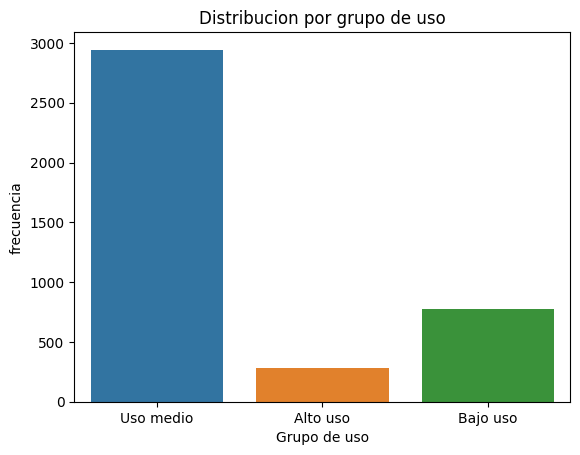

In [62]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribucion por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('frecuencia')
plt.show()


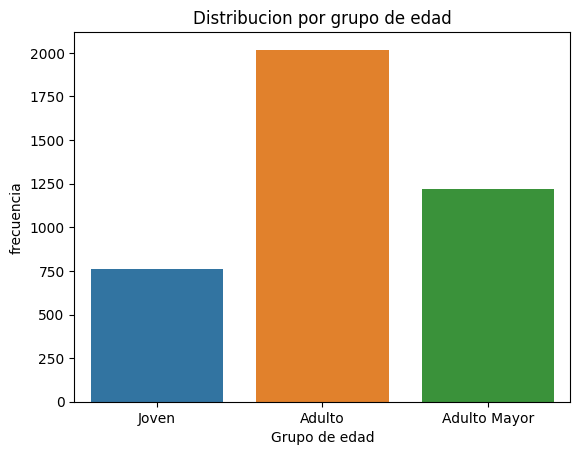

In [65]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad',order=['Joven','Adulto','Adulto Mayor'])
plt.title('Distribucion por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('frecuencia')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- en users las columnas city y churn_date tienen valores faltantes,mientras que en la columna usage los valores faltantes estan en date,duration y lenght.
- con city se tenia  el 11,75% de valores faltantes, por lo tanto se investigaria la importancia de esta fila antes de tomar una decision.
- churn_date se tenia el 88,35% de valores faltantes, este valor no representan un error pero es poco confiable por lo tanto deben mantenerse sin imputar ni eliminar.
- valores nulos en usage, date  representaba el 0,125% de los datos en cuanto duration y lenght me representan el 55,19% y 44,74% respectivamente.
- en la columna 'age' se encontraron valores sentinels con valor negativo de -999 y en la columna'city' se encontraron varios valores nulos(NaN)y sentinels con signo de interrogacion(?).
- en la columna reg_date se encontraron valores imposibles pues el dataset solo deberia contener datos hasta el año 2024 y contenia 40 datos del año 2026.
- en usage las columnas duration y length muestran que los valores nulos en duration se concentran casi exclusivamente en los registros de tipo text, mientras que los nulos en length se concentran en los registros de tipo call.

🔍 **Segmentos por Edad**
- el grupo dominante como se puede ver en el grafico es el de adulto y el de menor cantidad de usuarios es el grupo joven
- El grupo Adulto es el segmento dominante y muestra mayor tendencia hacia el plan Premium en comparación con otros grupos de edad.
  
📊 **Segmentos por Nivel de Uso**
- El segmento de Uso medio es el más grande, lo que indica que la mayoría de los clientes de ConnectaTel tienen un comportamiento de consumo moderado.

 **Manejo de Outliers**

en cant_mensajes se mantuvo los outliers pues es mas utilizado por clientes premium y eliminar esos outlier le costaria al negocio.
en cant_llamadas tambien se mantuvieron los outliers debido a que un número elevado de llamadas puede reflejar patrones legítimos de uso por parte de determinados clientes.
en cant_minutos_llamada: Se decidió mantener los outliers, ya que los usuarios pueden presentar una gran variabilidad en la duración de sus llamadas.

➡️ Esto sugiere que que existe un segmento de clientes con uso intensivo que podría estar generando los outlier que aunque son extraños son probables asi estos clientes hay que mantenerlos en el analisis pues son de gran importancia para la compañia...


💡 **Recomendaciones**
- al tener mayor cantidad de clientes adultos es importante continuar fidelizandolos ya sea con promociones o adherirles a los planes que manejan mayor cantidad de minutos y mensajes.
- ya que la mayoria de jovenes maneja el plan basico, se debe hacer camapañas,ofertas y descuentos para que adquieran el plan premium pues con este tienen mayor cantidad de minutos y mensajes.
- en los planes basicos al tener solo 100 minutos para llamadas se vieron outliers de 155 minutos por lo tanto es importante agregar mas minutos para el plan basico sin mayor costo pues esto tambien puede generar que al pasarse de los minutos permitidos por plan se genere un sobrecosto y eso genere que varios clientes se vayan de la compañia.

  

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`